In [1]:
from transformers import AutoModelForImageClassification, AutoImageProcessor

import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
import pandas as pd

from tqdm.notebook import trange, tqdm
from dotenv import load_dotenv
import os, json

from shared import freeze_model, load_cifar, make_dataloaders, create_clf_head, create_classification, train_model, plot_line

load_dotenv()
cudnn.benchmark = True
plt.ion();

# 5. CLS Token vs Mean-Pooled Patch Tokens

In [2]:
MODEL = "facebook/deit-tiny-patch16-224"
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
SAMPLES_BASE="task-2-imagenet-samples"
BASE = "vit-task"
BASE_PLOTS = os.path.join(BASE, "plots")

os.makedirs(BASE_PLOTS, exist_ok=True)
print(f"Using {DEVICE=}")

Using DEVICE='cuda'


In [3]:
BATCH_SIZE = 128
LR = 0.001
MOMENTUM=0.9
STEP_SIZE = 7
GAMMA = 0.1
N_EPOCHS = 50
BASE_PRECOMPUTED = os.path.join(BASE, "precomputed")

os.makedirs(BASE_PRECOMPUTED, exist_ok=True)

In [4]:
def load_model():
    processor = AutoImageProcessor.from_pretrained(MODEL)
    model = AutoModelForImageClassification.from_pretrained(MODEL, output_hidden_states=True).to(device=DEVICE)
    return processor, model

In [5]:
processor, model = load_model()
model = freeze_model(model).to(DEVICE)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
dataloaders, dataset_sizes = load_cifar(batch_size=BATCH_SIZE, num_workers=0)

In [13]:
def forward(model, image):
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(DEVICE, non_blocking=True) for k,v in inputs.items()}
    with torch.inference_mode():
        outputs = model(**inputs)
    return outputs

def precompute_vit_features(model, dataloader, save_dir):
    was_training = model.training
    model.eval()
    
    cls_dir = os.path.join(save_dir, "cls")
    mean_dir = os.path.join(save_dir, "mean")
    label_dir = os.path.join(save_dir, "label")
    
    os.makedirs(cls_dir, exist_ok=True)
    os.makedirs(mean_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)
    
    with torch.inference_mode():
        for i, (images, labels) in enumerate(tqdm(dataloader, total=len(dataloader))):
            outputs = forward(model, images)
            features = outputs.hidden_states[-1]
            
            cls_features = features[:,0,:].cpu()
            mean_features = features[:, 1:, :].mean(dim=1).cpu()
            
            fname = f"batch_{i:03}.pt"
            cls_path = os.path.join(cls_dir, fname)
            mean_path = os.path.join(mean_dir, fname)
            label_path = os.path.join(label_dir, fname)
            
            torch.save(cls_features, cls_path)
            torch.save(mean_features, mean_path)
            torch.save(labels, label_path)

            del outputs, features, cls_features, mean_features
            
    model.train(mode=was_training)

In [14]:
precompute_vit_features(model, dataloaders["val"], save_dir=os.path.join(BASE_PRECOMPUTED, "val"))
precompute_vit_features(model, dataloaders["train"], save_dir=os.path.join(BASE_PRECOMPUTED, "train"))

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

In [6]:
in_features = model.classifier.in_features

In [9]:
del dataloaders, dataset_sizes

In [10]:
del model, processor

In [11]:
class FeatureDataset(Dataset):
    def __init__(self, feature_dir, labels_dir):
        self.feature_dir = feature_dir
        self.labels_dir = labels_dir

        self.files = sorted(
            f for f in os.listdir(feature_dir)
            if f.endswith(".pt")
        )

        for f in self.files:
            if not os.path.exists(os.path.join(labels_dir, f)):
                raise FileNotFoundError(f"Missing label: {f}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]

        feature = torch.load(
            os.path.join(self.feature_dir, filename),
            map_location="cpu"
        )

        label = torch.load(
            os.path.join(self.labels_dir, filename),
            map_location="cpu"
        )

        feature = feature.float()
        label = torch.as_tensor(label).long()

        return feature, label

In [12]:
datasets = {
    phase: FeatureDataset(feature_dir=os.path.join(BASE_PRECOMPUTED, f"{phase}/cls"), labels_dir=os.path.join(BASE_PRECOMPUTED, f"{phase}/label"))
    for phase in ["train", "val"]
}
dataloaders, dataset_sizes = make_dataloaders(datasets, batch_size=None, n_workers=0)

classifier = create_clf_head(in_features).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(classifier, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [13]:
train_model("vit-task_cls-token", classifier, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Training complete in 4m 57s
Best val Acc: 27.810127


In [14]:
datasets = {
    phase: FeatureDataset(feature_dir=os.path.join(BASE_PRECOMPUTED, f"{phase}/mean"), labels_dir=os.path.join(BASE_PRECOMPUTED, f"{phase}/label"))
    for phase in ["train", "val"]
}
dataloaders, dataset_sizes = make_dataloaders(datasets, batch_size=None, n_workers=0)

classifier = create_clf_head(in_features).to(DEVICE)
criterion, optimizer, exp_sched = create_classification(classifier, lr=LR, momentum=MOMENTUM, step_size=STEP_SIZE, gamma=GAMMA)

In [15]:
train_model("vit-task_mean-pooled", classifier, criterion, optimizer, exp_sched, dataloaders, dataset_sizes, num_epochs=N_EPOCHS)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Training complete in 4m 57s
Best val Acc: 26.303797


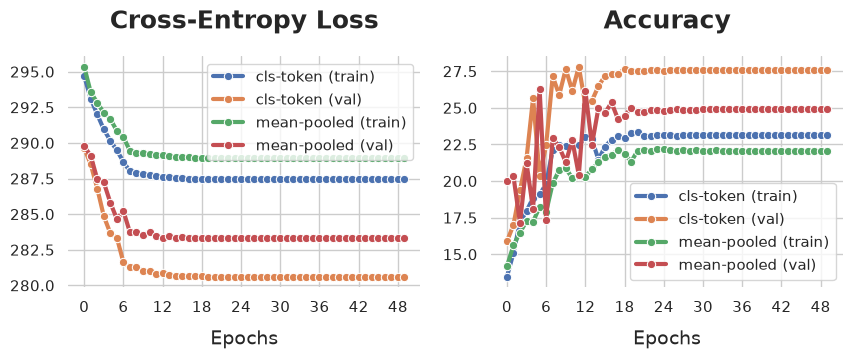

In [ ]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3))

for fname in ["vit-task_cls-token", "vit-task_mean-pooled"]:
    with open(f"{fname}.json", "r") as f:
        perf = json.loads(f.read())


    for phase in ["train", "val"]:
        perf_df = pd.DataFrame(perf[phase])
        label = fname.split("_")[-1]
        label = f"{label} ({phase})"
        lineplot_kwargs = dict(markersize=6, linewidth=3, label=label)
        
        configs = [
            {
                "column": "loss",
                "title": "Cross-Entropy Loss",
                "xlabel": "Epochs",
                "ylabel": "",
                "lineplot_kwargs": {**lineplot_kwargs, "ax": ax1},
            },
            {
                "column": "accuracy",
                "title": "Accuracy",
                "xlabel": "Epochs",
                "ylabel": "",
                "lineplot_kwargs": {**lineplot_kwargs, "ax": ax2},
            },
        ]
        
        plot_line(perf_df, configs)

plt.savefig(os.path.join(BASE_PLOTS, "vit-cls-vs-mean.pdf"), bbox_inches="tight", dpi=300)
plt.show()